In [9]:
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import muon as mu
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

In [85]:
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Set up directories
results_dir = Path(config['results_dir'])
metadata_dir = Path(config['metadata_dir'])

In [86]:
adata = ad.read_h5ad(results_dir/"adata_unified.h5ad")
#Divide by run
adata_145 = adata[adata.obs["run"] == 145]
adata_141 = adata[adata.obs["run"] == 141]

In [87]:
#arcsinh transformation 
adata_145.X = np.arcsinh(adata_145.X)
mu.prot.pp.clr(adata_145, axis=1)


/Users/jawadalaaedeen/miniconda3/envs/markers_comp_env/lib/python3.10/site-packages/anndata/_core/anndata.py:602: FutureWarning: You are attempting to set `X` to a matrix on a view which has non-unique indices. The resulting `adata.X` will likely not equal the value to which you set it. To avoid this potential issue, please make a copy of the data first. In the future, this operation will throw an error.
  warnings.warn(msg, FutureWarning, stacklevel=1)
/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_3556/2637161665.py:2: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  adata_145.X = np.arcsinh(adata_145.X)
/Users/jawadalaaedeen/miniconda3/envs/markers_comp_env/lib/python3.10/site-packages/muon/_prot/preproc.py:238: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  adata.X = x


/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_3556/3639005149.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(markers, rotation=90)
/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_3556/3639005149.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(markers, rotation=90)
/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_3556/3639005149.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(markers, rotation=90)
/var/folders/zj/m3tnl76s7d5894m0ndctg1kh0000gn/T/ipykernel_3556/3639005149.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(markers, r

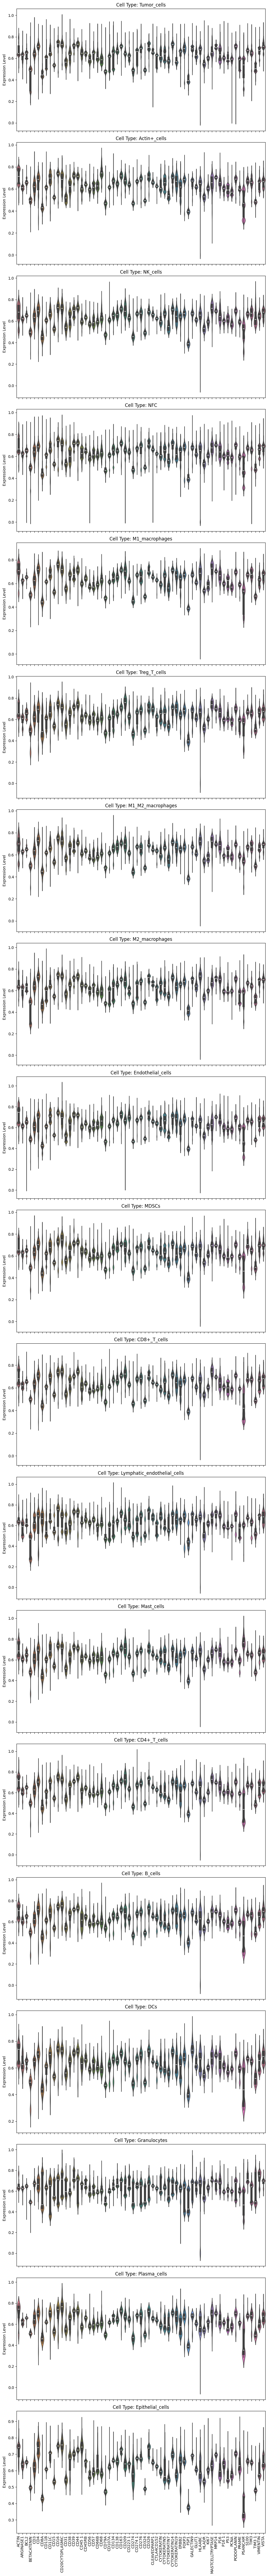

In [88]:
#violin plot of all markers for each cell type
markers = adata_145.var_names.tolist()
cell_types = adata_145.obs["cell_type"].unique().tolist()
n_markers = len(markers)
n_cell_types = len(cell_types)
fig, axes = plt.subplots(n_cell_types, 1, figsize=(10, 5*n_cell_types), sharex=True)
for i, cell_type in enumerate(cell_types):
    ax = axes[i]
    data = adata_145[adata_145.obs["cell_type"] == cell_type].to_df()
    sns.violinplot(data=data, ax=ax)
    ax.set_title(f'Cell Type: {cell_type}')
    ax.set_ylabel('Expression Level')
    ax.set_xticklabels(markers, rotation=90)
plt.tight_layout()

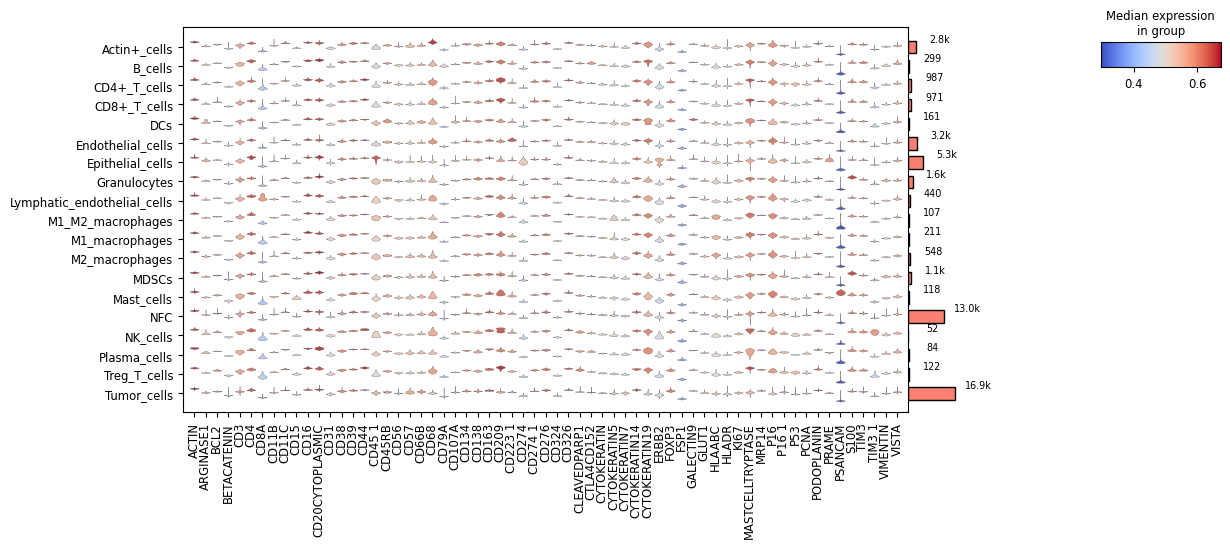

In [37]:
plot = sc.pl.stacked_violin(adata_145, adata.var_names, groupby='cell_type', cmap='coolwarm', use_raw=False, density_norm='area', figsize=(12, 5), return_fig=True)
plot.add_totals()
axes = plot.get_axes()
group_ax = axes['group_extra_ax']
for text in group_ax.texts:
    current_pos = text.get_position()
    text.set_position((current_pos[0] + 7, current_pos[1]+4))
axes['color_legend_ax'].set_position([0.89, 0.80, 0.1, 0.05])
fig = axes['mainplot_ax'].figure